In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Basic information
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Plot price trend
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Rolling Mean
df["RollingMean30"] = df["Price"].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Price"], label="Price")
plt.plot(df["Date"], df["RollingMean30"], label="30-day Rolling Mean")
plt.legend()
plt.show()

# Log Returns
import numpy as np

df["Log_Return"] = np.log(df["Price"]).diff()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Log Returns")
plt.show()

# Stationarity Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Log_Return"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Basic information
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

# Plot price trend
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Price"])
plt.title("Brent Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Rolling Mean
df["RollingMean30"] = df["Price"].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Price"], label="Price")
plt.plot(df["Date"], df["RollingMean30"], label="30-day Rolling Mean")
plt.legend()
plt.show()

# Log Returns
import numpy as np

df["Log_Return"] = np.log(df["Price"]).diff()

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Log_Return"])
plt.title("Log Returns")
plt.show()

# Stationarity Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Log_Return"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

In [1]:
# =====================================================
# Brent Oil Price Change Point Analysis
# Task 1 - Exploratory Data Analysis (EDA)
# =====================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Brent Oil Price Change Point Analysis

## Exploratory Data Analysis (EDA)

**Objective**

The objective of this notebook is to explore the historical Brent crude oil price dataset, understand its characteristics, identify trends and volatility, and prepare the data for Bayesian Change Point Analysis.


## 1. Load the Dataset

In this section, the Brent oil price dataset will be loaded, inspected, and prepared for analysis.

## 2. Data Cleaning

The following preprocessing steps will be performed:

- Convert the Date column to datetime format.
- Check for missing values.
- Check for duplicate records.
- Verify data types.

In [8]:
# Create a clean copy of the dataset

df_clean = df.copy()

# Convert Date column to datetime format

df_clean["Date"] = pd.to_datetime(df_clean["Date"])

# Check data types after conversion

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9927 entries, 0 to 9926
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9927 non-null   datetime64[us]
 1   Price   9927 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 155.2 KB


In [9]:
# Check missing values

df_clean.isnull().sum()

Date     0
Price    0
dtype: int64

In [10]:
# Check duplicate rows

df_clean.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

The exploratory analysis will include:

- Summary statistics
- Price trend visualization
- Rolling averages
- Rolling volatility
- Log returns
- Stationarity testing

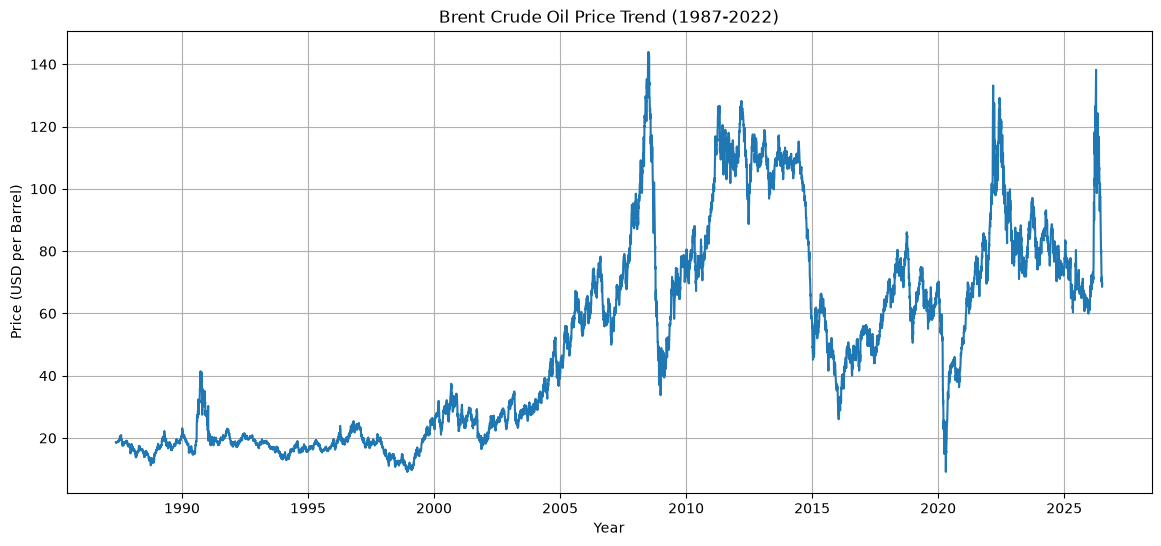

In [11]:
# Plot Brent oil price trend over time

plt.figure(figsize=(14,6))

plt.plot(
    df_clean["Date"],
    df_clean["Price"]
)

plt.title("Brent Crude Oil Price Trend (1987-2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")

plt.grid(True)
plt.show()

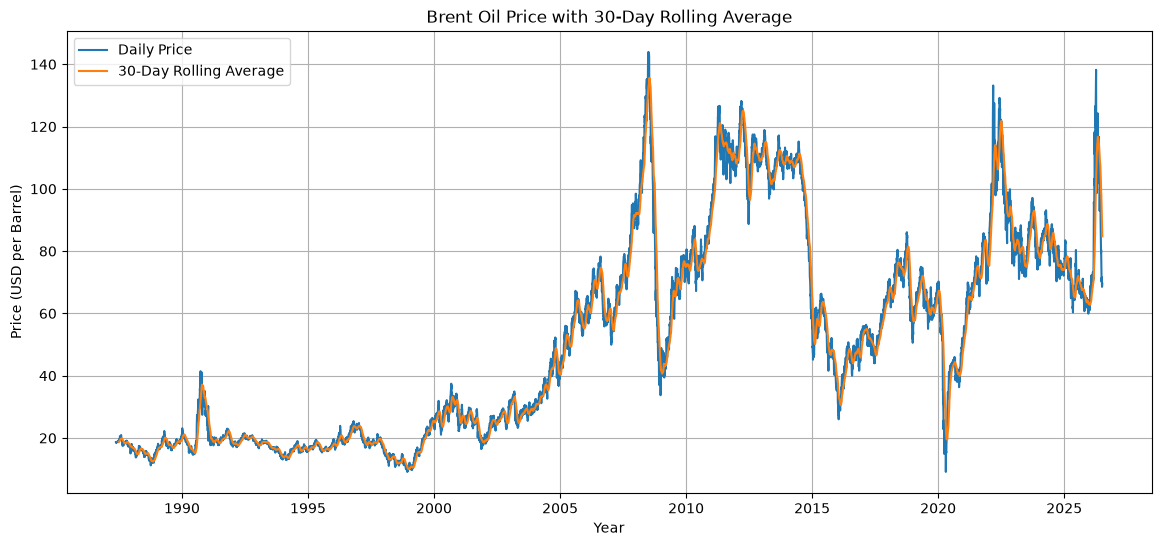

In [12]:
# Calculate 30-day rolling average

df_clean["Rolling_Mean_30"] = df_clean["Price"].rolling(window=30).mean()


# Plot price with rolling average

plt.figure(figsize=(14,6))

plt.plot(
    df_clean["Date"],
    df_clean["Price"],
    label="Daily Price"
)

plt.plot(
    df_clean["Date"],
    df_clean["Rolling_Mean_30"],
    label="30-Day Rolling Average"
)

plt.title("Brent Oil Price with 30-Day Rolling Average")
plt.xlabel("Year")
plt.ylabel("Price (USD per Barrel)")

plt.legend()
plt.grid(True)

plt.show()

## 4. Initial Findings

This section will summarize the key observations from the exploratory analysis and discuss how they inform the Bayesian Change Point model.

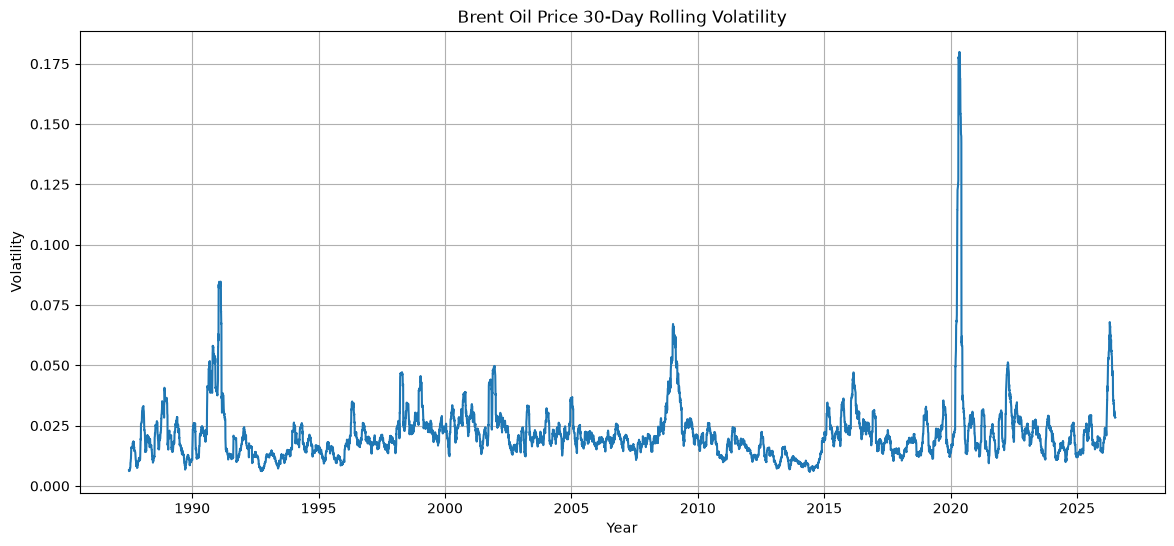

In [13]:
# Calculate daily price changes

df_clean["Daily_Return"] = df_clean["Price"].pct_change()


# Calculate rolling volatility (30 days)

df_clean["Rolling_Volatility_30"] = (
    df_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)


# Plot rolling volatility

plt.figure(figsize=(14,6))

plt.plot(
    df_clean["Date"],
    df_clean["Rolling_Volatility_30"]
)

plt.title("Brent Oil Price 30-Day Rolling Volatility")
plt.xlabel("Year")
plt.ylabel("Volatility")

plt.grid(True)

plt.show()

In [4]:
# Load the Brent Oil Prices dataset

import pandas as pd

file_path = "../data/raw/BrentOilPrices.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("❌ Dataset not found. Please check the file path.")

✅ Dataset loaded successfully!
Shape: (9927, 2)


In [5]:
df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9927 entries, 0 to 9926
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9927 non-null   str    
 1   Price   9927 non-null   float64
dtypes: float64(1), str(1)
memory usage: 155.2 KB


In [ ]:
# Display the first five rows
df.head()

In [ ]:
# Dataset information
df.info()

In [ ]:
# Summary statistics
df.describe()

In [ ]:
# Check for missing values
df.isnull().sum()

In [7]:
df.describe()

,Price
count,9927.000000
mean,51.285829
std,32.766723
min,9.100000
25%,19.580000
50%,46.320000
75%,74.875000
max,143.950000


In [14]:

# Calculate log returns

df_clean["Log_Return"] = np.log(
    df_clean["Price"] / df_clean["Price"].shift(1)
)


# Display first rows

df_clean[["Date", "Price", "Log_Return"]].head()

,Date,Price,Log_Return
0,1987-05-20,18.63,NaN
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612


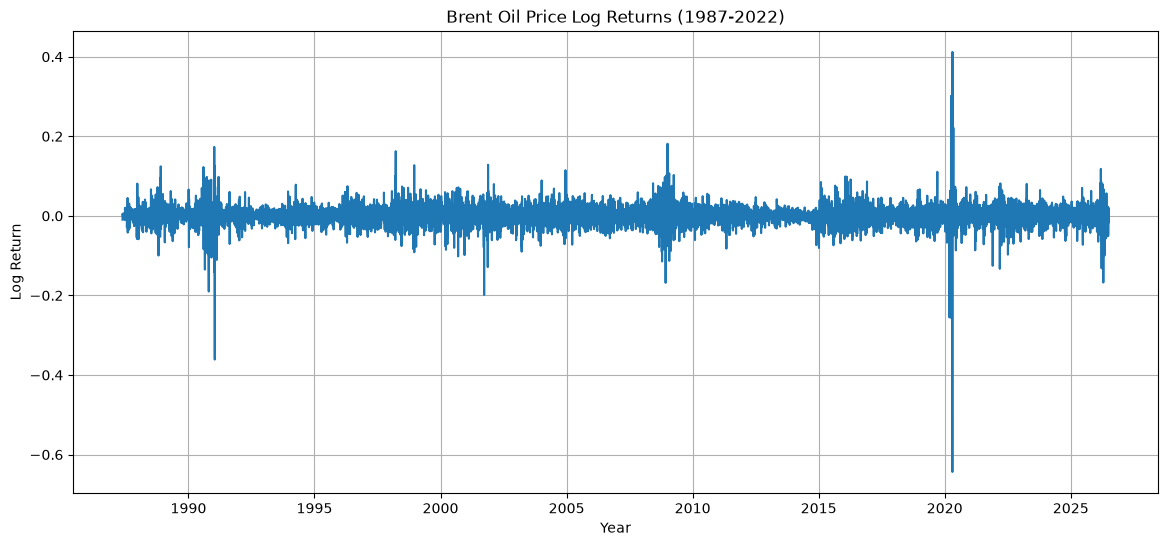

In [15]:
# Plot log returns

plt.figure(figsize=(14,6))

plt.plot(
    df_clean["Date"],
    df_clean["Log_Return"]
)

plt.title("Brent Oil Price Log Returns (1987-2022)")
plt.xlabel("Year")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [16]:
# Augmented Dickey-Fuller (ADF) test on log returns

adf_result = adfuller(
    df_clean["Log_Return"].dropna()
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -16.947540187507084
p-value: 9.51513578261404e-30

Critical Values:
1%: -3.4310110406491767
5%: -2.8618321403033673
10%: -2.5669255011501515


## ADF Stationarity Test Results

The Augmented Dickey-Fuller (ADF) test was applied to the Brent oil price log returns to evaluate stationarity.

### Hypotheses

- **Null Hypothesis (H0):** The time series is non-stationary.
- **Alternative Hypothesis (H1):** The time series is stationary.

### Results

The ADF statistic was:

**-16.9475**

The p-value was:

**9.515 × 10⁻³⁰**

The p-value is significantly lower than the 0.05 significance level, and the ADF statistic is more negative than the critical values.

Therefore, the null hypothesis is rejected, indicating that the log return series is stationary.

### Conclusion

The stationary log return series can be used as an input for further statistical modeling, including Bayesian Change Point Analysis, to identify periods where the behavior of Brent oil prices changed significantly.


In [17]:
# Save cleaned dataset

output_path = "../data/processed/brent_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
